<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/Currency-Prediction-Project/PROPHET_Model_Currencies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
!pip install Prophet
from prophet import Prophet

In [258]:
#loading data
data =pd.read_csv("/content/Foreign_Exchange_Rates.xls")
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [259]:
#dropping null values and converting timeseries to datetime
data.dropna()
data['Time Serie'] = pd.to_datetime(data['Time Serie'], format='%d-%m-%Y')

In [260]:
#Pre-processing
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [261]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Unnamed: 0                                 5217 non-null   int64         
 1   Time Serie                                 5217 non-null   datetime64[ns]
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object        
 3   EURO AREA - EURO/US$                       5217 non-null   object        
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object        
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object        
 6   BRAZIL - REAL/US$                          5217 non-null   object        
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object        
 8   CHINA - YUAN/US$                           5217 non-null   object        
 9   HONG KONG - HONG KO

In [262]:
# drop unnamed columns
data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,...,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,...,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,...,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,...,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5212,2019-12-25,ND,ND,ND,ND,ND,ND,ND,ND,ND,...,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
5213,2019-12-26,1.4411,0.9007,1.5002,0.7688,4.0602,1.3124,6.9949,7.788,71.28,...,1.354,6.7295,109.67,4.1337,8.8799,9.4108,181.3,0.9808,30.11,30.15
5214,2019-12-27,1.4331,0.8949,1.4919,0.7639,4.0507,1.3073,6.9954,7.7874,71.45,...,1.352,6.6829,109.47,4.126,8.8291,9.3405,181.35,0.9741,30.09,30.14
5215,2019-12-30,1.4278,0.8915,1.4846,0.761,4.0152,1.3058,6.9864,7.7857,71.3,...,1.3483,6.6589,108.85,4.1053,8.7839,9.3145,181.6,0.9677,30.04,29.94


In [263]:
#batch converting column objects to float types
rates = data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

for col in rates.columns:
    rates[col] = pd.to_numeric(rates[col], errors='coerce')

    print(rates)
print(rates.info())

               Time Serie AUSTRALIA - AUSTRALIAN DOLLAR/US$  \
0      946857600000000000                            1.5172   
1      946944000000000000                            1.5239   
2      947030400000000000                            1.5267   
3      947116800000000000                            1.5291   
4      947203200000000000                            1.5272   
...                   ...                               ...   
5212  1577232000000000000                                ND   
5213  1577318400000000000                            1.4411   
5214  1577404800000000000                            1.4331   
5215  1577664000000000000                            1.4278   
5216  1577750400000000000                            1.4225   

     EURO AREA - EURO/US$ NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
0                  0.9847                              1.9033   
1                    0.97                              1.9238   
2                  0.9676                       

In [264]:
#forward/backward fill to correct NaN anomalies

rates.fillna(rates.ffill(), inplace=True)

In [265]:
#converting time feature to datetime again with newly converted data
rates['Time Serie'] = pd.to_datetime(rates['Time Serie'], format='mixed')
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5217 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   float64       
 2   EURO AREA - EURO/US$                       5217 non-null   float64       
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   float64       
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   float64       
 5   BRAZIL - REAL/US$                          5217 non-null   float64       
 6   CANADA - CANADIAN DOLLAR/US$               5217 non-null   float64       
 7   CHINA - YUAN/US$                           5217 non-null   float64       
 8   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   float64       
 9   INDIA - INDIAN RUPE

In [266]:
#rennaming date and chosen currency columns into ds/y format for prophet model

df_prophet = rates[["Time Serie", "THAILAND - BAHT/US$"]].rename(columns = {"Time Serie": "ds", "THAILAND - BAHT/US$":"y"})

df_prophet.head()

,ds,y
0,2000-01-03,36.97
1,2000-01-04,37.13
2,2000-01-05,37.10
3,2000-01-06,37.62
4,2000-01-07,37.30


In [267]:
model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [268]:
future_dates = pd.date_range(start = "2020-01-01", periods = 30, freq = "D")

In [269]:
future_df = pd.DataFrame({"ds": future_dates})

In [270]:
future_df.head()

,ds
0,2020-01-01
1,2020-01-02
2,2020-01-03
3,2020-01-04
4,2020-01-05


In [271]:
#making forecasts

forecast = model.predict(future_df)

forecast[["ds","yhat","yhat_lower","yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2020-01-01,30.255820,29.573786,31.003796
1,2020-01-02,30.243482,29.496396,30.980258
2,2020-01-03,30.231106,29.519139,30.923977
3,2020-01-04,30.180882,29.433362,30.897098
4,2020-01-05,30.168393,29.442397,30.884213


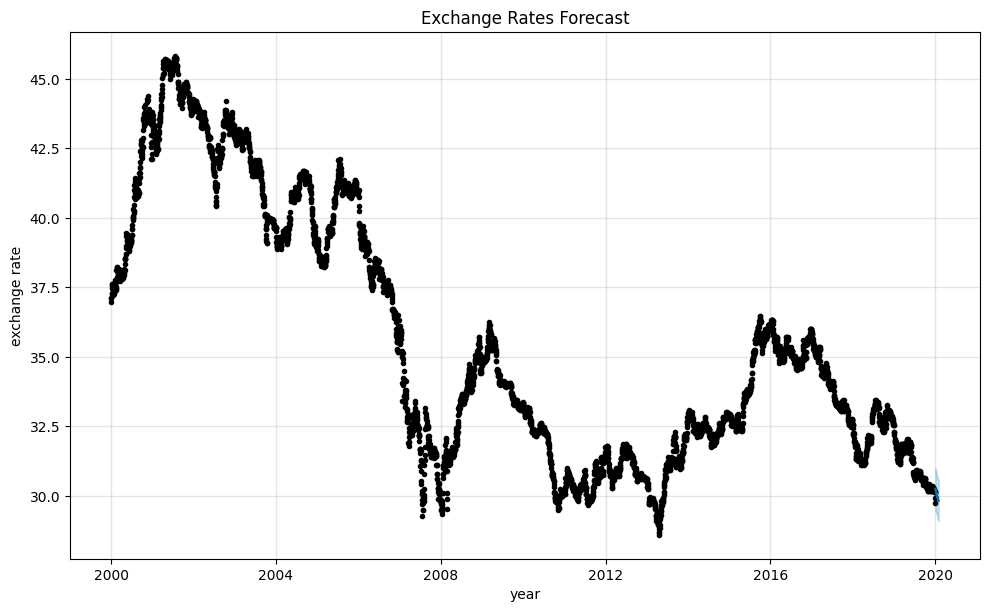

In [272]:
#visualisation

model.plot(forecast)
plt.title("Exchange Rates Forecast")
plt.xlabel("year")
plt.ylabel("exchange rate")
plt.show()

In [273]:
#evaluation metrics

from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(model, initial='365 days', period='180 days', horizon='30 days')

INFO:prophet:Making 39 forecasts with cutoffs between 2001-03-10 00:00:00 and 2019-12-01 00:00:00


  0%|          | 0/39 [00:00<?, ?it/s]

In [274]:
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'rmse', 'mape']])

   horizon       mae      rmse      mape
0   3 days  0.864388  1.162733  0.025809
1   4 days  0.856925  1.157375  0.025582
2   5 days  0.875293  1.200657  0.026057
3   6 days  0.928648  1.258586  0.027568
4   7 days  0.964621  1.276141  0.028539
5   8 days  0.965237  1.274437  0.028554
6   9 days  0.977636  1.282940  0.028926
7  10 days  0.968312  1.275975  0.028593
8  11 days  0.985451  1.301929  0.029040
9  12 days  0.992971  1.330235  0.029225
10 13 days  1.022048  1.356407  0.030070
11 14 days  1.026933  1.335214  0.030235
12 15 days  1.032097  1.318066  0.030413
13 16 days  1.045361  1.317118  0.030857
14 17 days  1.020073  1.297686  0.030060
15 18 days  0.998604  1.309726  0.029431
16 19 days  0.988206  1.323988  0.029026
17 20 days  1.032999  1.369096  0.030274
18 21 days  1.066925  1.369435  0.031279
19 22 days  1.100121  1.385810  0.032347
20 23 days  1.121471  1.394781  0.032993
21 24 days  1.074709  1.346923  0.031543
22 25 days  1.031719  1.325151  0.030265
23 26 days  1.01

In [275]:
#saving models
import joblib

In [276]:
joblib.dump(model, 'Thailand_model.pkl')

['Thailand_model.pkl']